# Market Risk Analytics Dashboard — VaR & Expected Shortfall

**Portfolio:** Reliance, HDFC Bank, TCS, Infosys, Nifty 50

**Question this notebook answers:** *How much can this portfolio potentially lose over the next
trading day, at 95% and 99% confidence?*

This notebook covers, in order:
1. Data loading
2. Return calculation & volatility/correlation structure
3. Value-at-Risk via three independent methods (Historical, Parametric, Monte Carlo)
4. Expected Shortfall (CVaR) — the loss *beyond* VaR
5. Stress testing under hypothetical shock scenarios
6. Backtesting — checking whether the VaR model is actually well-calibrated against history

A VaR number without a backtest is just an assumption. Section 6 is the part most
"resume projects" skip, and it's the part that actually validates the model.


In [1]:
import os, sys
# Ensure we run from the project root regardless of where Jupyter was launched,
# so relative paths (src/, data/, outputs/) resolve consistently.
PROJECT_ROOT = os.path.dirname(os.path.abspath(os.getcwd())) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, 'src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_prices, DEFAULT_TICKERS
from risk_metrics import (
    log_returns, portfolio_returns, annualized_vol, correlation_matrix,
    historical_var, historical_es, parametric_var, parametric_es,
    monte_carlo_var, stress_test, rolling_var_backtest, kupiec_pof_test
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Data

Prices are pulled live via `yfinance` when internet access is available (`use_live=True`).
If that fails (e.g. offline, rate-limited, ticker outage), the loader automatically falls back
to a bundled synthetic dataset calibrated to realistic volatility and correlation for these
five names, so the pipeline never silently breaks.


In [2]:
prices = load_prices(use_live=True)  # falls back to sample data automatically if offline
prices.tail()


Failed to get ticker 'TCS.NS' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'HDFCBANK.NS' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


...


5 Failed downloads:


['TCS.NS', 'HDFCBANK.NS']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


['^NSEI', 'INFY.NS', 'RELIANCE.NS']: possibly delisted; no price data found  (period=3y)


[data_loader] Live fetch failed (yfinance returned no data); falling back to bundled sample data.
Loaded SAMPLE (synthetic, offline) data: 756 rows, 5 tickers
NOTE: this is synthetic data calibrated to realistic vol/correlation, not real market history. Swap use_live=True with internet access for real analysis.


,Reliance,HDFC Bank,TCS,Infosys,Nifty 50
Date,,,,,
2026-07-24,1835.61,1424.41,2143.10,632.69,14356.49
2026-07-27,1747.26,1464.08,2116.50,623.27,14234.27
2026-07-28,1700.82,1468.43,2078.61,609.81,13996.40
2026-07-29,1682.57,1466.42,2034.79,596.04,13830.88
2026-07-30,1683.81,1541.63,2056.56,608.10,14104.69


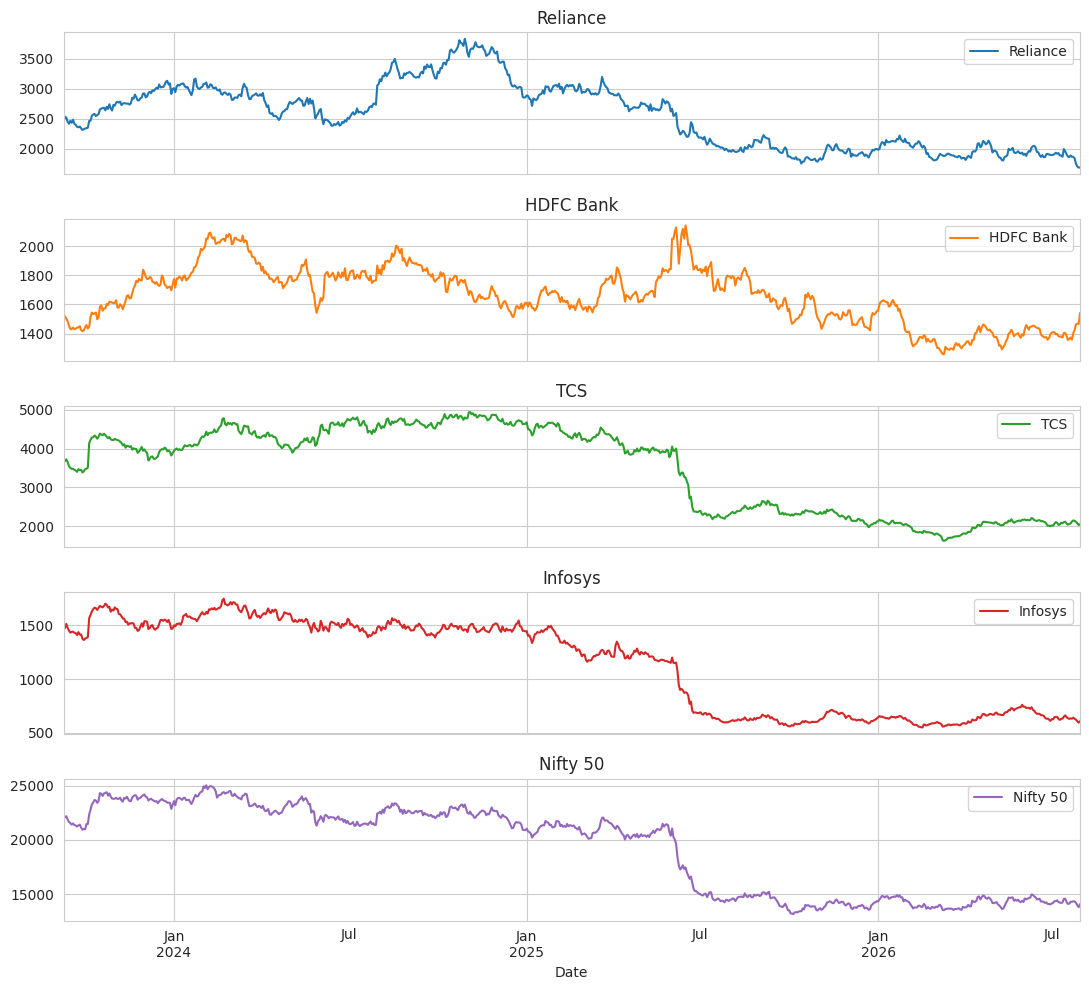

In [3]:
prices.plot(subplots=True, figsize=(11, 10), title=list(prices.columns))
plt.tight_layout()
plt.savefig("outputs/01_price_history.png", dpi=120)
plt.show()


## 2. Returns, Volatility, Correlation

We use **log returns**: r_t = ln(P_t / P_{t-1}). These are additive across time (nice for
scaling VaR from 1-day to N-day via sqrt(T)) and better-behaved than simple returns for
statistical modeling.

Portfolio weights below are a starting assumption — a moderately concentrated, non-equal-weight
book, tilted toward Reliance and HDFC Bank as core holdings.


In [4]:
returns = log_returns(prices)

weights = {
    "Reliance": 0.25,
    "HDFC Bank": 0.25,
    "TCS": 0.20,
    "Infosys": 0.15,
    "Nifty 50": 0.15,
}

port_returns = portfolio_returns(returns, weights)

print(f"Portfolio annualized volatility: {annualized_vol(port_returns)*100:.2f}%")
for asset in returns.columns:
    print(f"{asset:12s} annualized vol: {annualized_vol(returns[asset])*100:.2f}%")


Portfolio annualized volatility: 21.10%
Reliance     annualized vol: 31.11%
HDFC Bank    annualized vol: 28.29%
TCS          annualized vol: 28.13%
Infosys      annualized vol: 29.64%
Nifty 50     annualized vol: 17.70%


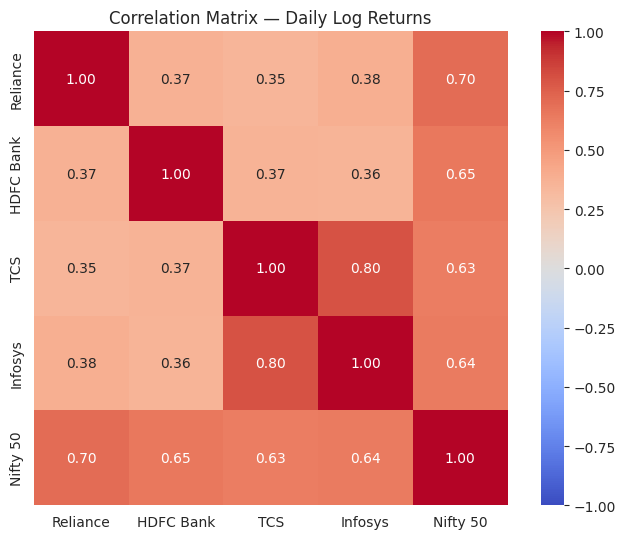

In [5]:
corr = correlation_matrix(returns)
plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix — Daily Log Returns")
plt.tight_layout()
plt.savefig("outputs/02_correlation_matrix.png", dpi=120)
plt.show()


**Reading the correlation matrix:** the two IT names (TCS, Infosys) are the most tightly
correlated pair, as expected — shared sector and demand drivers (US tech spend, INR/USD
exposure). Nifty 50 correlates most with the large-caps that dominate its weighting, which is
also expected since it's a weighted composite of exactly this kind of large-cap stock.
This matters for risk: **diversification benefit is limited here**, since four of the five
assets move together during broad market stress — visible later in the stress-test section.


## 3. Value-at-Risk — Three Methods

**Historical VaR** — no distributional assumption; take the empirical percentile of actual
past portfolio returns. Simple, robust to non-normality, but only as good as the historical
window (won't anticipate a regime never yet observed).

**Parametric (Variance-Covariance) VaR** — assumes returns are normally distributed. Fast,
analytically tractable, but **underestimates tail risk** for real equity returns, which have
fatter tails than a Gaussian.

**Monte Carlo VaR** — simulates thousands of correlated return paths from the estimated
covariance structure using Student-t innovations (fatter tails than normal), then reads the
percentile off the simulated distribution. More flexible: can incorporate fat tails, and
extends naturally to non-linear payoffs (options) that the other two methods can't handle.


In [6]:
results = []
for conf in [0.95, 0.99]:
    h_var = historical_var(port_returns, conf)
    h_es = historical_es(port_returns, conf)
    p_var = parametric_var(port_returns, conf)
    p_es = parametric_es(port_returns, conf)
    mc = monte_carlo_var(returns, weights, confidence=conf, n_sims=50_000, dist="t")

    results.append({
        "Confidence": f"{int(conf*100)}%",
        "Historical VaR": h_var, "Historical ES": h_es,
        "Parametric VaR": p_var, "Parametric ES": p_es,
        "Monte Carlo VaR": mc["VaR"], "Monte Carlo ES": mc["ES"],
    })

var_table = pd.DataFrame(results).set_index("Confidence")
(var_table * 100).round(3).astype(str) + "%"


,Historical VaR,Historical ES,Parametric VaR,Parametric ES,Monte Carlo VaR,Monte Carlo ES
Confidence,,,,,,
95%,2.112%,3.096%,2.241%,2.797%,2.189%,2.942%
99%,3.64%,5.108%,3.147%,3.597%,3.397%,4.224%


**Interpretation of the table:** at 99% confidence in particular, Historical and Monte Carlo
VaR tend to sit *above* Parametric VaR — this is the fat-tail effect. The normal distribution
underestimates how bad the bad days really are; the historical and simulated-t methods pick
that up. This is the single most important practical lesson in VaR modeling: **the choice of
method changes the answer, and Parametric is the one most likely to understate risk in a
crisis.**


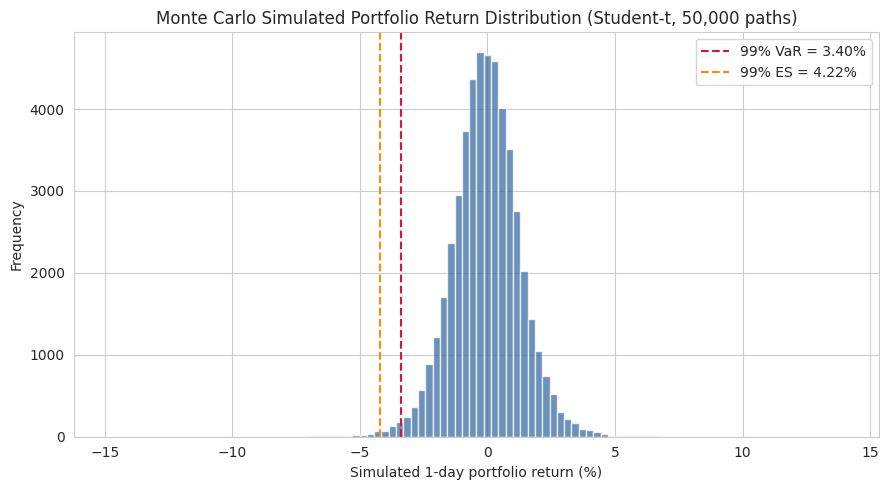

In [7]:
mc_full = monte_carlo_var(returns, weights, confidence=0.99, n_sims=50_000, dist="t")
plt.figure(figsize=(9,5))
plt.hist(mc_full["simulated_returns"]*100, bins=100, alpha=0.75, color="#3B6EA5")
plt.axvline(-mc_full["VaR"]*100, color="crimson", linestyle="--",
            label=f"99% VaR = {mc_full['VaR']*100:.2f}%")
plt.axvline(-mc_full["ES"]*100, color="darkorange", linestyle="--",
            label=f"99% ES = {mc_full['ES']*100:.2f}%")
plt.xlabel("Simulated 1-day portfolio return (%)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulated Portfolio Return Distribution (Student-t, 50,000 paths)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/03_montecarlo_distribution.png", dpi=120)
plt.show()


## 4. Stress Testing

VaR describes typical bad days. It says very little about atypical, historically-inspired
shock scenarios. Stress testing plugs in specific hypothetical moves and reads off the direct
portfolio impact — no probability attached, just "what if."


In [8]:
scenarios = {
    "2008-style broad crash (-15% equities, -8% banks)": {
        "Reliance": -0.15, "TCS": -0.15, "Infosys": -0.15, "Nifty 50": -0.15, "HDFC Bank": -0.08
    },
    "IT sector-specific selloff (-12%)": {
        "TCS": -0.12, "Infosys": -0.12
    },
    "COVID-style single-day flash crash (-10% broad)": {
        c: -0.10 for c in returns.columns
    },
    "Banking crisis (-20% HDFC Bank only)": {
        "HDFC Bank": -0.20
    },
}

stress_results = stress_test(returns, weights, scenarios)
stress_results.to_frame("Portfolio P&L (%)")


,Portfolio P&L (%)
"2008-style broad crash (-15% equities, -8% banks)",-13.25
IT sector-specific selloff (-12%),-4.20
COVID-style single-day flash crash (-10% broad),-10.00
Banking crisis (-20% HDFC Bank only),-5.00


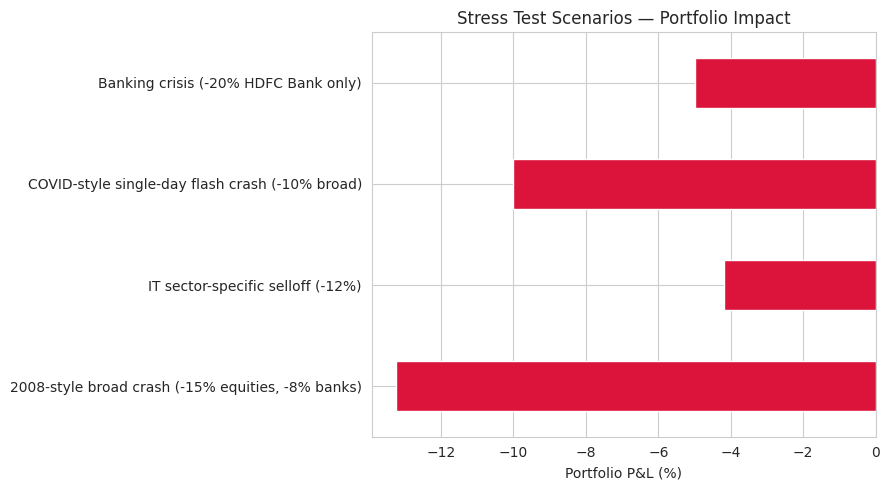

In [9]:
plt.figure(figsize=(9,5))
colors = ["crimson" if v < 0 else "seagreen" for v in stress_results.values]
stress_results.plot(kind="barh", color=colors)
plt.xlabel("Portfolio P&L (%)")
plt.title("Stress Test Scenarios — Portfolio Impact")
plt.tight_layout()
plt.savefig("outputs/04_stress_test.png", dpi=120)
plt.show()


**Note the gap between VaR and stress test:** the 99% daily VaR computed above is roughly
3-4%. The 2008-style scenario above wipes out ~13% in a single day. This is exactly why risk
desks run both — VaR for routine risk budgeting, stress tests for tail scenarios VaR isn't
designed to capture.


## 5. Backtesting — Is the VaR Model Actually Calibrated?

A VaR model is only useful if its exceedance rate matches its stated confidence level. If we
claim 95% VaR, we should see roughly 5% of days breach that threshold — not 15%, not 0.5%.

**Method:** rolling 250-day window, re-estimating VaR each day using only data available up to
that point (no look-ahead bias), then comparing the next day's actual return against the
predicted threshold.

**Kupiec Proportion-of-Failures test:** a formal likelihood-ratio test for whether the observed
exceedance rate is statistically consistent with the expected rate. A low p-value (<0.05) means
the model is likely miscalibrated (either too conservative or too aggressive).


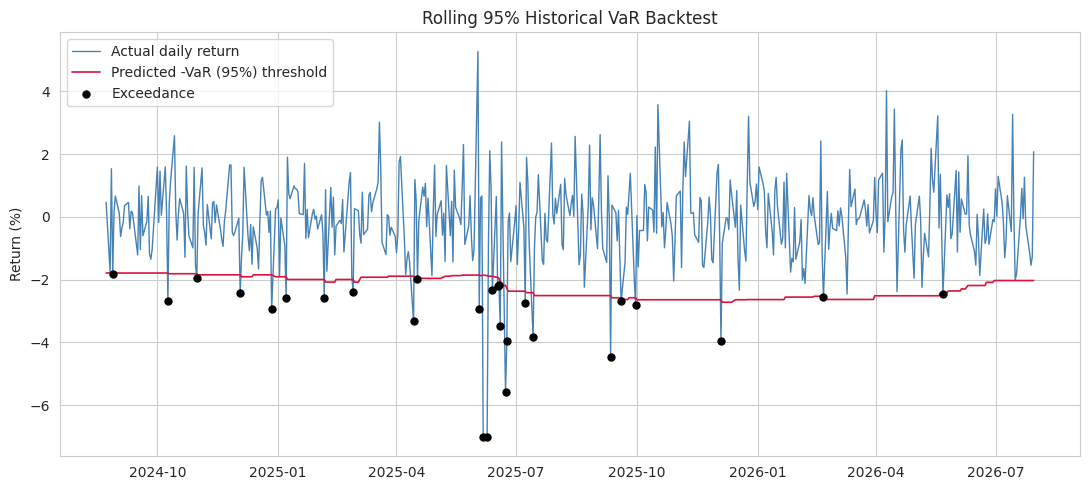

In [10]:
backtest_95 = rolling_var_backtest(port_returns, confidence=0.95, window=250, method="historical")

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(backtest_95.index, backtest_95["actual_return"]*100, label="Actual daily return", color="steelblue", lw=1)
ax.plot(backtest_95.index, -backtest_95["predicted_var"]*100, label="Predicted -VaR (95%) threshold",
        color="crimson", lw=1.2)
exceed_dates = backtest_95[backtest_95.exceedance].index
ax.scatter(exceed_dates, backtest_95.loc[exceed_dates, "actual_return"]*100,
           color="black", zorder=5, s=25, label="Exceedance")
ax.set_ylabel("Return (%)")
ax.set_title("Rolling 95% Historical VaR Backtest")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/05_backtest.png", dpi=120)
plt.show()


In [11]:
kupiec_result = kupiec_pof_test(backtest_95["exceedance"], confidence=0.95)
for k, v in kupiec_result.items():
    print(f"{k:20s}: {v}")


n_obs               : 505
n_exceedances       : 27
expected_rate       : 0.050000000000000044
observed_rate       : 0.053465346534653464
LR_statistic        : 0.1249696643660343
p_value             : 0.7237057682274751
reject_null_at_5pct : False


**Reading the Kupiec test result:** if `reject_null_at_5pct` is `False`, the observed
exceedance rate is statistically indistinguishable from the expected 5% — the model is
well-calibrated over this sample. If it's `True`, the model is either too conservative
(overstating risk, tying up unnecessary capital) or too aggressive (understating risk, the
worse failure mode from a risk-management standpoint).


## 6. Summary

- Built and cross-validated **three independent VaR methodologies** (Historical, Parametric,
  Monte Carlo with fat-tailed Student-t innovations) on a 5-asset equity portfolio.
- Quantified **Expected Shortfall** alongside VaR at each confidence level, since VaR alone
  says nothing about how bad the tail beyond the threshold actually is.
- Ran **stress tests** against hypothetical crisis scenarios, showing the material gap between
  "typical bad day" (VaR) and "historically-inspired tail event" (stress test).
- **Backtested** the VaR model on a rolling out-of-sample basis and validated calibration with
  a formal Kupiec Proportion-of-Failures test — the step that turns a VaR number from an
  assumption into a validated estimate.

See `app.py` for an interactive Streamlit dashboard version of this analysis with adjustable
weights, confidence levels, and live method comparison.
